### Dataset Overview

1) Target Analysis

2) Feature Analysis
       
3) Correlation Analysis
       
4) Zero-Value Analysis
       
5) Outlier Analysis
       
6) Feature Distributions
       
7) EDA Complete 

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../artifacts/train.csv")

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,84,0,0,0,0.0,0.304,21,0
1,9,112,82,24,0,28.2,1.282,50,1
2,1,139,46,19,83,28.7,0.654,22,0
3,0,161,50,0,0,21.9,0.254,65,0
4,6,134,80,37,370,46.2,0.238,46,1


In [5]:
df.shape

(614, 9)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               614 non-null    int64  
 1   Glucose                   614 non-null    int64  
 2   BloodPressure             614 non-null    int64  
 3   SkinThickness             614 non-null    int64  
 4   Insulin                   614 non-null    int64  
 5   BMI                       614 non-null    float64
 6   DiabetesPedigreeFunction  614 non-null    float64
 7   Age                       614 non-null    int64  
 8   Outcome                   614 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 43.3 KB


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.742671,120.855049,69.415309,20.399023,81.438111,31.983388,0.469168,32.907166,0.346906
std,3.313264,32.035057,18.512599,15.433974,116.234835,7.740625,0.336847,11.503437,0.476373
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,100.000000,64.000000,0.000000,0.000000,27.100000,0.241500,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,42.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,139.000000,80.000000,32.000000,129.750000,36.375000,0.613750,40.000000,1.000000
max,17.000000,199.000000,122.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df["Outcome"].value_counts()

Outcome
0    401
1    213
Name: count, dtype: int64

In [9]:
df["Outcome"].value_counts(normalize = True)

Outcome
0    0.653094
1    0.346906
Name: proportion, dtype: float64

In [10]:
import matplotlib.pyplot as plt

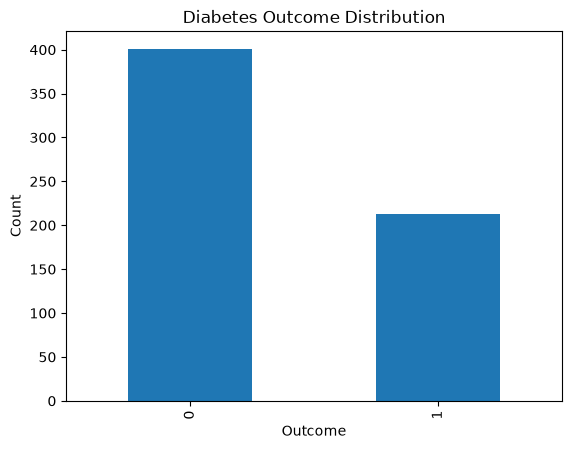

In [11]:
df["Outcome"].value_counts().plot(kind = "bar")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.title("Diabetes Outcome Distribution")
plt.show()

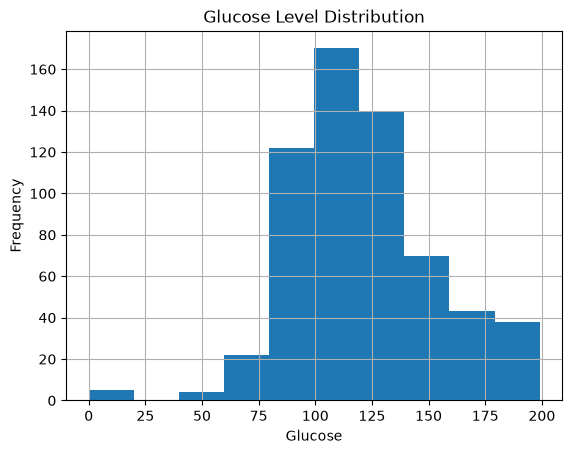

In [12]:
df["Glucose"].hist()
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.title("Glucose Level Distribution")
plt.show()

In [13]:
df.groupby("Outcome")["Glucose"].mean()

Outcome
0    110.214464
1    140.887324
Name: Glucose, dtype: float64

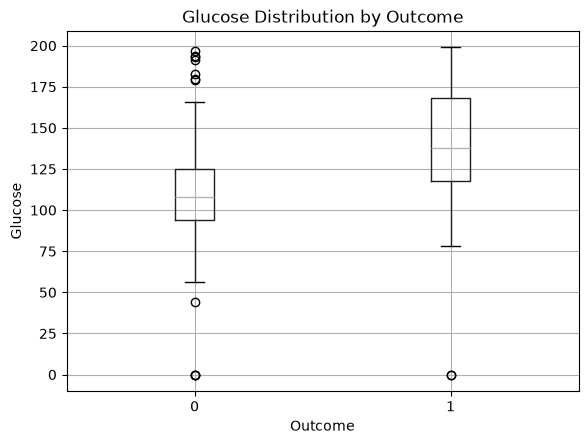

In [14]:
df.boxplot(column="Glucose", by="Outcome")
plt.xlabel("Outcome")
plt.ylabel("Glucose")
plt.title("Glucose Distribution by Outcome")
plt.suptitle("")
plt.show()

In [15]:
df.groupby("Outcome")["Glucose"].agg(["count", "mean", "median", "min","max"])

,count,mean,median,min,max
Outcome,,,,,
0,401,110.214464,108.0,0,197
1,213,140.887324,138.0,0,199


In [16]:
## here correlation analysis starts
correlation_matrix = df.corr()

In [17]:
correlation_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.142507,0.157544,-0.070691,-0.066401,0.027197,-0.018944,0.553048,0.207550
Glucose,0.142507,1.000000,0.158320,0.017320,0.337064,0.205162,0.141597,0.270740,0.456117
BloodPressure,0.157544,0.158320,1.000000,0.178062,0.085834,0.250012,0.044826,0.239588,0.082046
SkinThickness,-0.070691,0.017320,0.178062,1.000000,0.437564,0.386223,0.174623,-0.149863,0.057912
Insulin,-0.066401,0.337064,0.085834,0.437564,1.000000,0.196035,0.158923,-0.043823,0.108498
BMI,0.027197,0.205162,0.250012,0.386223,0.196035,1.000000,0.131945,0.004453,0.306335
DiabetesPedigreeFunction,-0.018944,0.141597,0.044826,0.174623,0.158923,0.131945,1.000000,0.020052,0.154560
Age,0.553048,0.270740,0.239588,-0.149863,-0.043823,0.004453,0.020052,1.000000,0.280654
Outcome,0.207550,0.456117,0.082046,0.057912,0.108498,0.306335,0.154560,0.280654,1.000000


In [18]:
import seaborn as sns

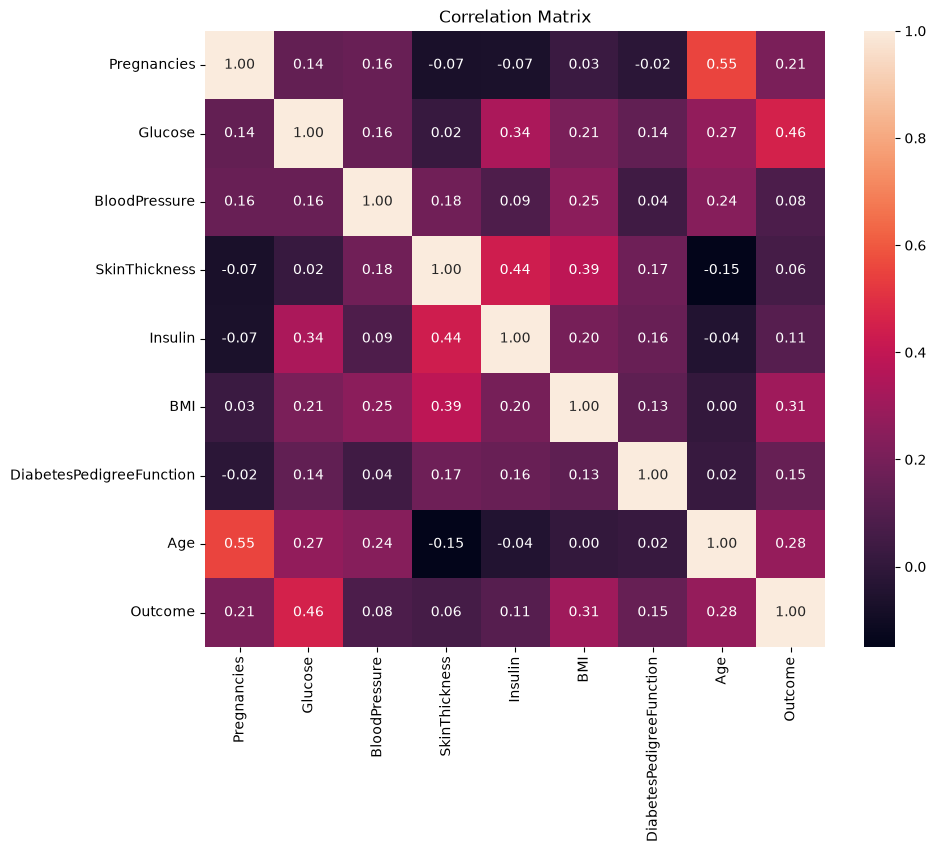

In [19]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

In [20]:
zero_counts = (df == 0).sum()
zero_counts

Pregnancies                  91
Glucose                       5
BloodPressure                24
SkinThickness               176
Insulin                     290
BMI                           7
DiabetesPedigreeFunction      0
Age                           0
Outcome                     401
dtype: int64

In [21]:
df == 0

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,True,True,True,True,False,False,True
1,False,False,False,False,True,False,False,False,False
2,False,False,False,False,False,False,False,False,True
3,True,False,False,True,True,False,False,False,True
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
609,False,False,False,False,False,False,False,False,True
610,False,False,False,True,True,False,False,False,True
611,False,False,False,False,True,False,False,False,False
612,True,False,True,True,True,False,False,False,False


In [22]:
zero_counts = (df == 0).sum()
zero_counts


Pregnancies                  91
Glucose                       5
BloodPressure                24
SkinThickness               176
Insulin                     290
BMI                           7
DiabetesPedigreeFunction      0
Age                           0
Outcome                     401
dtype: int64

In [25]:
zero_sensitive_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
zero_percentage = (df[zero_sensitive_columns] == 0).mean() * 100
zero_percentage

Glucose           0.814332
BloodPressure     3.908795
SkinThickness    28.664495
Insulin          47.231270
BMI               1.140065
dtype: float64

In [26]:
zero_percentage* 100

Glucose            81.433225
BloodPressure     390.879479
SkinThickness    2866.449511
Insulin          4723.127036
BMI               114.006515
dtype: float64

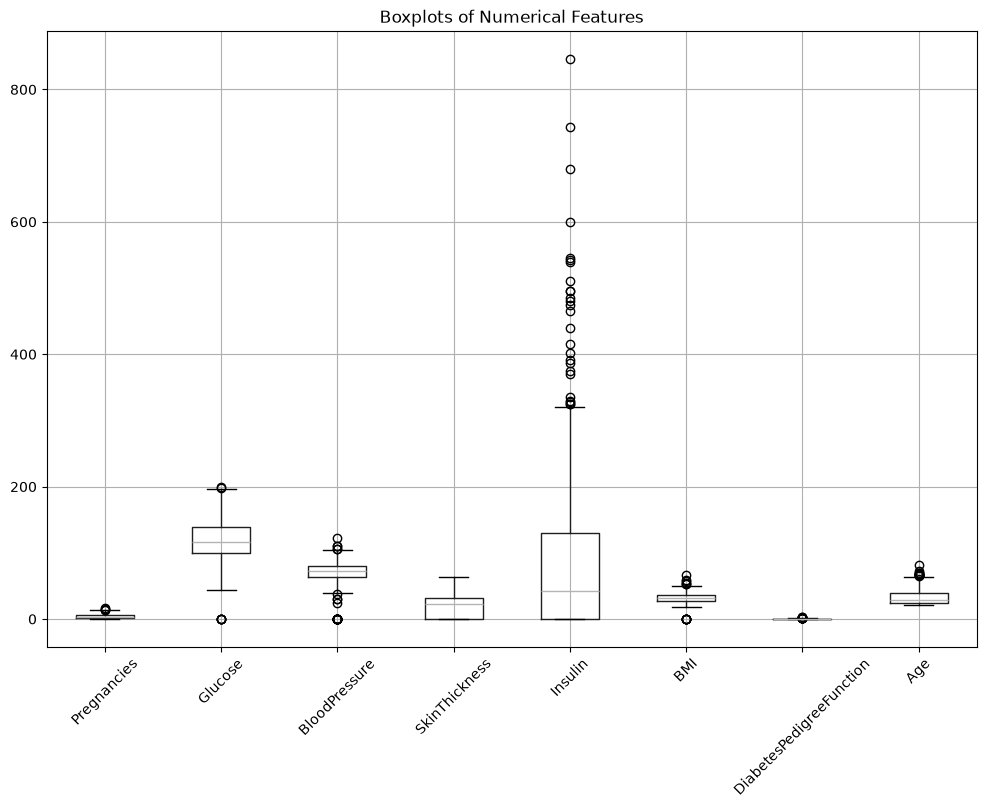

In [27]:
df.boxplot(
    column=[
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age"
    ],
    figsize=(12, 8)
)

plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.show()

In [28]:
numerical_features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

In [29]:
Q1 = df[numerical_features].quantile(0.25)
Q3 = df[numerical_features].quantile(0.75)

In [30]:
IQR = Q3 - Q1

In [31]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [32]:
outlier_counts = (
    (df[numerical_features] < lower_bound) |
    (df[numerical_features] > upper_bound)
).sum()

In [33]:
df[numerical_features] > upper_bound

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True
4,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...
609,False,False,False,False,False,False,False,False
610,False,False,True,False,False,False,False,False
611,False,False,False,False,False,False,False,False
612,False,False,False,False,False,False,False,False


In [34]:
df[numerical_features] > upper_bound.sum()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
609,False,False,False,False,False,False,False,False
610,False,False,False,False,False,False,False,False
611,False,False,False,False,False,False,False,False
612,False,False,False,False,False,False,False,False


In [35]:
outlier_counts

Pregnancies                  4
Glucose                      7
BloodPressure               33
SkinThickness                0
Insulin                     26
BMI                         13
DiabetesPedigreeFunction    26
Age                         13
dtype: int64

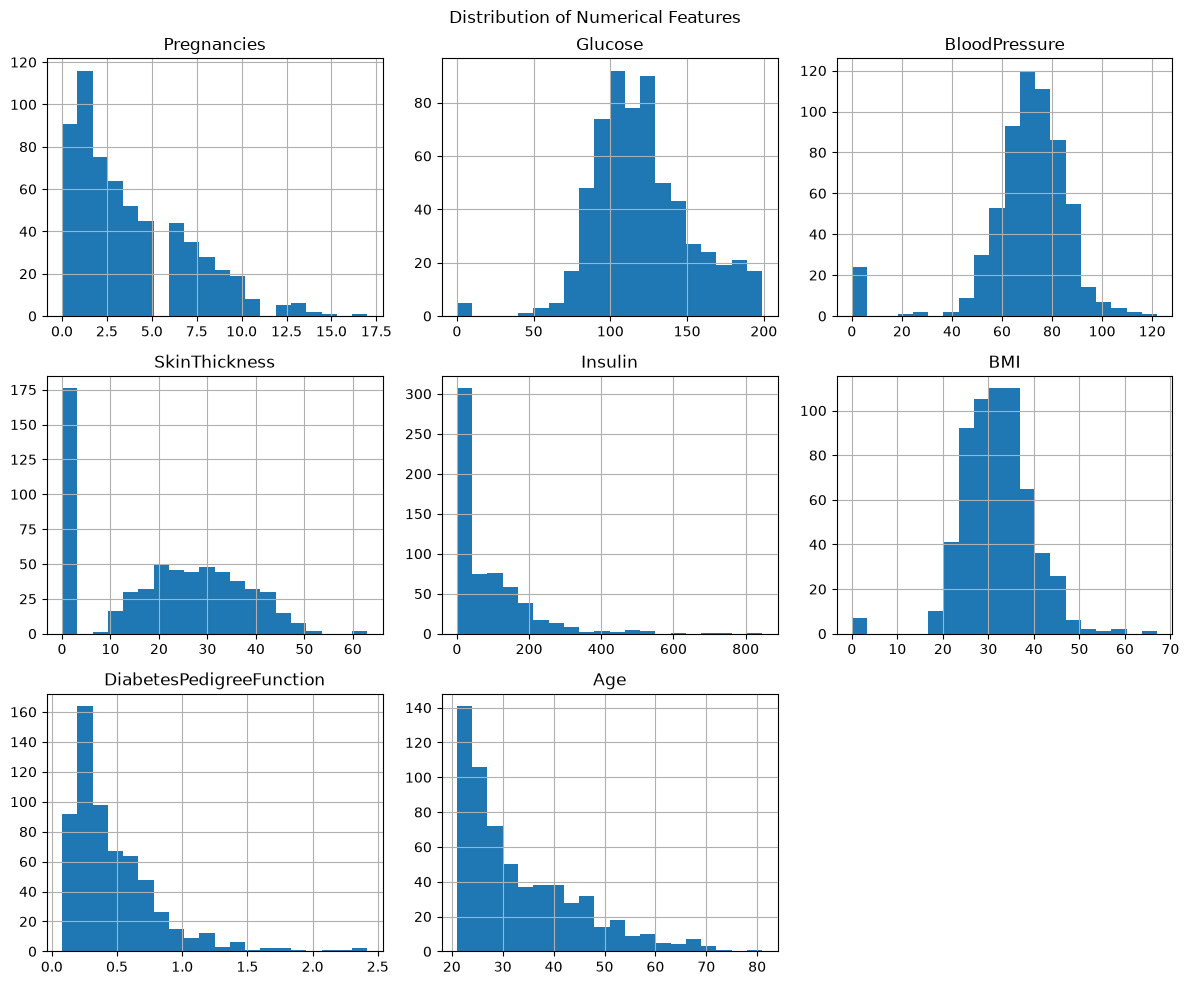

In [36]:
# Feature Distributions
df[numerical_features].hist(
    figsize=(12, 10),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()